In [1]:
import numpy as np
import sklearn

_Создадим столбец признаков объекта, которые будут равномерно распределены в отрезке 0-20._

In [2]:
#np.random.rand() - случайные числа 0-1, в скобках размер матрицы
X = 20 * np.random.rand(120, 1)

_Создадим гаусовский шум._

In [3]:
noise = np.random.normal(loc=0.0, scale=5, size=X.shape)

_Создадим правильный ответ и добавим к нему шум._

In [4]:
Y = X * 2 + noise
Y

array([[12.80483927],
       [32.89605596],
       [18.65657721],
       [32.25707574],
       [11.14467737],
       [12.53562853],
       [10.42735234],
       [27.89898773],
       [ 2.74021185],
       [23.02558206],
       [ 6.60908882],
       [12.27390761],
       [-3.4010603 ],
       [27.04888216],
       [-0.96795701],
       [31.30470469],
       [40.03165076],
       [11.7591462 ],
       [35.30371858],
       [33.91296796],
       [16.03419018],
       [42.98915176],
       [22.53186227],
       [15.0020878 ],
       [ 9.94546426],
       [11.80603911],
       [27.76300808],
       [45.95148021],
       [16.53525276],
       [ 3.69066968],
       [23.61370305],
       [14.91986634],
       [ 7.35703266],
       [28.73242914],
       [28.57334189],
       [14.33924271],
       [37.50416287],
       [34.54406941],
       [41.62559109],
       [ 7.13858834],
       [30.68484094],
       [35.86436293],
       [23.90939399],
       [30.48879485],
       [36.20936279],
       [12

_Разделим данные на train и test._

In [5]:
from sklearn.model_selection import train_test_split
#40 % процентов тестовой выборки
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

In [6]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((72, 1), (48, 1), (72, 1), (48, 1))

#### **Построим линейную модель.**

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=False) #без b
#обучим модель
model.fit(X_train, Y_train)
#посмотрим на её коэффициент
model.coef_

array([[1.984849]])

_Функция для изображения графиков._

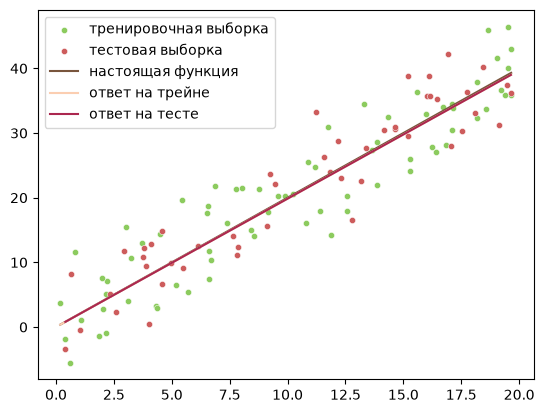

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def holst(x_train, y_train, x_test, y_test, predict_train, predict_test):
    plt.figure()

    #превращаем все переменные в одномерные массивы
    x_train = np.ravel(x_train)
    y_train = np.ravel(y_train)
    x_test = np.ravel(x_test)
    y_test = np.ravel(y_test)
    predict_train = np.ravel(predict_train)
    predict_test = np.ravel(predict_test)

    #сохраняем индексы для сортировки
    idx_train = np.argsort(x_train)
    idx_test = np.argsort(x_test)

    #изобразим тренировочную выборку
    sns.scatterplot(
        x=x_train,
        y=y_train,
        color="#8ccb5e",
        s=20,
        label="тренировочная выборка"
    )
    #изобразим тестовую выборку
    sns.scatterplot(
        x=x_test,
        y=y_test,
        color="#cd5c5c",
        s=20,
        label="тестовая выборка"
    )
    #изобразим настоящую функцию
    #также сделав векторы одномерными
    sns.lineplot(
        x=np.ravel(X),
        y=np.ravel(2 * X),
        color="#79553d",
        label="настоящая функция"
    )
    #изобразим ответ на трейне
    #отсортировав их по индексам
    sns.lineplot(
        x=x_train[idx_train],
        y=predict_train[idx_train],
        color="#fbceb1",
        label="ответ на трейне"
    )
    #изобразим ответ на тесте
    #отсортировав их по индексам
    sns.lineplot(
        x=x_test[idx_test],
        y=predict_test[idx_test],
        color="#ab274f",
        label="ответ на тесте"
    )
    #отобразим легенду
    plt.legend()
    #отобразим весь график
    plt.show()
holst(X_train, Y_train, X_test, Y_test, model.predict(X_train), model.predict(X_test))

#### **Построим полиномиальную модель.**

_Добавим степенные признаки._

In [9]:
#скопируем старые признаки
X_pol = X.copy()
#добавим новые признаки
for k in range(2, 26):
    x_new = X ** k
    X_pol = np.hstack([X_pol, x_new])
X_pol.shape

(120, 25)

_Снова разделим выборку на тестовую и трейн._

In [10]:
X_pol_train, X_pol_test, Y_pol_train, Y_pol_test = train_test_split(X_pol, Y, test_size=0.4, random_state=42)

In [11]:
X_pol_train.shape, X_pol_test.shape

((72, 25), (48, 25))

_Обучим новую модель._

In [12]:
model_pol = LinearRegression()
model_pol.fit(X_pol_train, Y_pol_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 25)","[[ 0.,-0.,-0.,..., 0.,-0., 0.]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[14.82]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,25
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](25,)","[4.36e+32,3.21e+29,6.77e+26,...,3.27e+01,5.74e-01,1.13e-04]"


_Изобразим её._

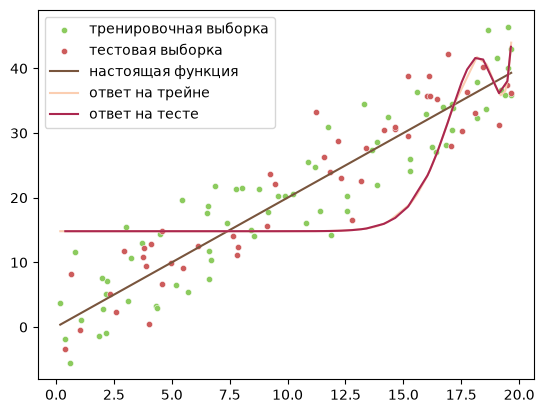

In [21]:
#найдем ответы для трейна
ans_train = model_pol.predict(X_pol_train)
#найдем ответы для теста
ans_test = model_pol.predict(X_pol_test)

#передаем в функцию только первый столбец признаков
holst(X_pol_train[:, 0], Y_pol_train, X_pol_test[:, 0], Y_pol_test, ans_train, ans_test)

_Найдем ошибку на трейне и на тесте._

In [20]:
er_train = np.mean((ans_train - Y_train)**2)
er_test = np.mean((ans_test - Y_test)**2)

#посмотрим на результат
print('ошибка на трейне:', round(er_train, 2))
print('ошибка на тесте:', round(er_test, 2))

ошибка на трейне: 71.87
ошибка на тесте: 93.43


#### **Попробуем регулярезировать полиномиальную модель.**

_Видим, что все признаки разного порядка._

In [14]:
X_pol

array([[4.08159920e+00, 1.66594520e+01, 6.79972060e+01, ...,
        1.11969100e+14, 4.57012987e+14, 1.86534384e+15],
       [1.59969986e+01, 2.55903965e+02, 4.09369537e+03, ...,
        4.93043986e+27, 7.88722397e+28, 1.26171911e+30],
       [6.56091200e+00, 4.30455662e+01, 2.82418172e+02, ...,
        6.16846190e+18, 4.04707357e+19, 2.65524935e+20],
       ...,
       [1.97530114e+00, 3.90181459e+00, 7.70725879e+00, ...,
        6.30327449e+06, 1.24508653e+07, 2.45942083e+07],
       [1.70489784e+01, 2.90667664e+02, 4.95558672e+03, ...,
        2.13335085e+28, 3.63714525e+29, 6.20096107e+30],
       [1.86233861e+00, 3.46830512e+00, 6.45915854e+00, ...,
        1.62685524e+06, 3.02975533e+06, 5.64243034e+06]], shape=(120, 25))

_Для этого отмасштабируем их._

In [17]:
from sklearn.preprocessing import StandardScaler

#класс для стандартизации признаков
scaler = StandardScaler()
#вычислим все нужные значения для стандартизации
#среднее, стандартное отклонения и тд.
#эти данные вычисляются именно на тестовых данных
scaler.fit(X_pol_train)
#теперь получим измененные данные
X_pol_transformed_train = scaler.transform(X_pol_train)
X_pol_transformed_test = scaler.transform(X_pol_test)

_Теперь обучим Ridge-регрессияю._

In [28]:
from sklearn.linear_model import Ridge

#обучим модель
model_ridge = Ridge()
model_ridge.fit(X_pol_transformed_train, Y_train)

#получим её предсказание
predict_ridge_train = model_ridge.predict(X_pol_transformed_train)
predict_ridge_test= model_ridge.predict(X_pol_transformed_test)

#вычислим её ошибку
error_train = np.mean((predict_ridge_train - Y_train)**2)
error_test = np.mean((predict_ridge_test - Y_train)**2)

#посмотрим на результат
print('ошибка на трейне:', round(error_train, 2))
print('ошибка на тесте:', round(error_test, 2))

ошибка на трейне: 302.92
ошибка на тесте: 288.1


_Изобразим результат._

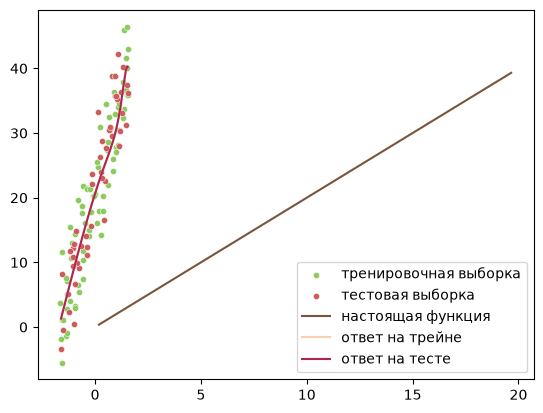

In [26]:
#передаем в функцию только первый столбец признаков
holst(X_pol_transformed_train[:, 0], Y_pol_train, X_pol_transformed_test[:, 0], Y_pol_test, predict_ridge_train, predict_ridge_test)